In [1]:
%load_ext autoreload
%autoreload 2

# RNN Model Training

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import joblib
import matplotlib.dates as mdates
from sklearn.metrics import  r2_score
# set up relative imports
project_folder = Path.cwd().parent.parent
sys.path.append(str(project_folder))

In [2]:
from modeling.model.lstm import create_lstm_model, get_callbacks
from modeling.utilities.data_prep import setup_sequential_data

#### read in data

In [3]:
data_folder = Path(r'..\data\model-ready\water-weather')

# train
train_X_df = pd.read_parquet(data_folder / 'scaled-X-train.parquet')
train_y_df = pd.read_parquet(data_folder / 'scaled-Y-train.parquet') # the Y data is not actually scaled inspite of the name

# test
test_X_df = pd.read_parquet(data_folder / 'scaled-X-test.parquet')
test_y_df = pd.read_parquet(data_folder / 'scaled-Y-test.parquet') # the Y data is not actually scaled inspite of the name

# val
val_X_df = pd.read_parquet(data_folder / 'scaled-X-val.parquet')
val_y_df = pd.read_parquet(data_folder / 'scaled-Y-val.parquet') # the Y data is not actually scaled inspite of the name



In [4]:
scaler = joblib.load(data_folder / 'minmax_scaler.joblib')

#### set up sequential data

In [22]:
# train
train_X_df.reset_index(drop=True, inplace=True)
train_y_df.reset_index(drop=True, inplace=True)

# test
test_X_df.reset_index(drop=True, inplace=True)
test_y_df.reset_index(drop=True, inplace=True)

# val
val_X_df.reset_index(drop=True, inplace=True)
val_y_df.reset_index(drop=True, inplace=True)

In [26]:
seq_size = 10
X_train, y_train, y_idx_train = setup_sequential_data(train_X_df, train_y_df, seq_size)
X_val, y_val, y_idx_val =  setup_sequential_data(val_X_df, val_y_df, seq_size)
X_test, y_test, y_idx_test =  setup_sequential_data(test_X_df, test_y_df, seq_size)

### Compile and Train the model

In [27]:
input_shape = (X_train.shape[1], X_train.shape[2])

In [28]:
model = create_lstm_model(input_shape)

In [29]:
model.compile(optimizer='adam', loss='mse',)

In [30]:
history = model.fit(X_train, 
          y_train, 
          epochs=100, 
          batch_size=32,
          validation_data=(X_val, y_val),
          callbacks=get_callbacks()
          )

Epoch 1/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 24.0690 - val_loss: 7.0118 - learning_rate: 0.0010
Epoch 2/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 8.0507 - val_loss: 3.1935 - learning_rate: 0.0010
Epoch 3/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 2.7021 - val_loss: 1.1602 - learning_rate: 0.0010
Epoch 4/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 2.0420 - val_loss: 0.7475 - learning_rate: 0.0010
Epoch 5/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 1.8560 - val_loss: 0.5559 - learning_rate: 0.0010
Epoch 6/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 1.7883 - val_loss: 0.5004 - learning_rate: 0.0010
Epoch 7/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 1.7570 - val_loss: 0.4328 - learning_rate: 0.0010
Epoch 8/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 1.6933 - val_loss: 0.3758 - learning_rate: 0.0010
Epoch 9/100
689/689 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 1.6539 - val_loss: 0.3307 - learning_ra

#### Evaluate the model

In [31]:
y_pred = model.predict(X_test)

151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step


In [33]:
test_x_unscaled = scaler.inverse_transform(test_X_df)
test_x_df = pd.DataFrame(columns=test_X_df.columns, data=test_x_unscaled)

In [34]:
test_x_df.shape

(4832, 16)

In [35]:
results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred.flatten()
}, index=y_idx_test)

In [36]:
results_df

,actual,predicted
9,14.30,14.426868
10,15.10,15.036185
11,15.10,15.101036
12,15.20,15.188444
13,14.80,14.763648
...,...,...
4827,17.40,17.330620
4828,17.25,17.167990
4829,17.10,17.027328
4830,17.20,17.207685


In [37]:
len(y_pred)

4823

In [38]:
test_x_df = test_x_df.join(results_df,
                how='inner')

In [39]:
test_x_df['date'] = pd.to_datetime(test_x_df[['year','month','day']], errors='coerce')

In [40]:
test_x_df['errors'] = test_x_df.predicted - test_x_df.actual

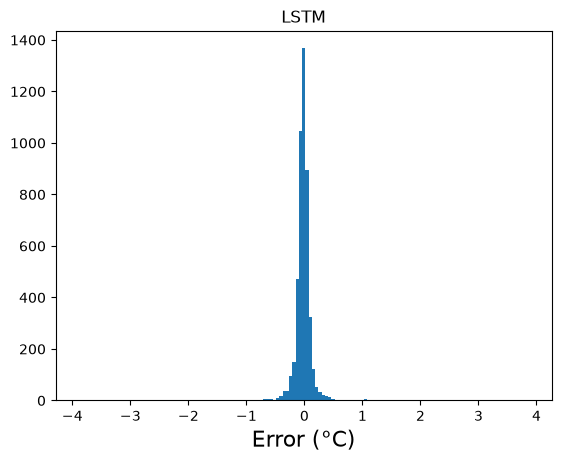

In [41]:
plt.hist(test_x_df.errors, bins='auto')
plt.title('LSTM')
plt.xlabel('Error (\u00b0C)', fontsize=16)
plt.show()

In [48]:
test_x_df[: 20]

,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,tmax_c,tmin_c,sin_month,cos_month,sin_day,cos_day,past_10_day_ave_temp,past_10_day_std_temp,actual,predicted,date,errors
9,66.0,49.0,0.00,15.1,15.1,2.0,12.0,1940.0,18.888889,9.444444,0.866025,0.5,0.651372,-0.758758,15.49,0.490918,14.3,14.426868,1940-02-12,0.126868
10,67.0,45.0,0.00,15.0,15.1,2.0,13.0,1940.0,19.444444,7.222222,0.866025,0.5,0.485302,-0.874347,15.43,0.498999,15.1,15.036185,1940-02-13,-0.063815
11,62.0,46.0,0.20,15.3,15.2,2.0,14.0,1940.0,16.666667,7.777778,0.866025,0.5,0.299363,-0.954139,15.37,0.485455,15.1,15.101036,1940-02-14,0.001036
12,62.0,49.0,0.00,14.8,14.8,2.0,15.0,1940.0,16.666667,9.444444,0.866025,0.5,0.101168,-0.994869,15.27,0.490011,15.2,15.188444,1940-02-15,-0.011556
13,65.0,42.0,0.00,14.5,14.5,2.0,16.0,1940.0,18.333333,5.555556,0.866025,0.5,-0.101168,-0.994869,15.14,0.505964,14.8,14.763648,1940-02-16,-0.036352
14,65.0,44.0,0.02,15.1,15.1,2.0,17.0,1940.0,18.333333,6.666667,0.866025,0.5,-0.299363,-0.954139,15.05,0.406202,14.5,14.524727,1940-02-17,0.024727
15,62.0,49.0,0.05,14.9,14.9,2.0,18.0,1940.0,16.666667,9.444444,0.866025,0.5,-0.485302,-0.874347,14.99,0.375500,15.1,15.035053,1940-02-18,-0.064947
16,70.0,46.0,0.00,14.7,14.7,2.0,19.0,1940.0,21.111111,7.777778,0.866025,0.5,-0.651372,-0.758758,14.92,0.355278,14.9,14.892763,1940-02-19,-0.007237
17,76.0,44.0,0.00,14.4,14.5,2.0,20.0,1940.0,24.444444,6.666667,0.866025,0.5,-0.790776,-0.612106,14.82,0.311983,14.7,14.644734,1940-02-20,-0.055266
18,67.0,53.0,0.13,13.3,14.5,2.0,21.0,1940.0,19.444444,11.666667,0.866025,0.5,-0.897805,-0.440394,14.84,0.279682,14.5,14.524508,1940-02-21,0.024508


In [44]:
pd.DataFrame(test_x_df.errors.describe()).T.round(3)

,count,mean,std,min,25%,50%,75%,max
errors,4823.0,-0.022,0.267,-3.897,-0.074,-0.019,0.033,3.874


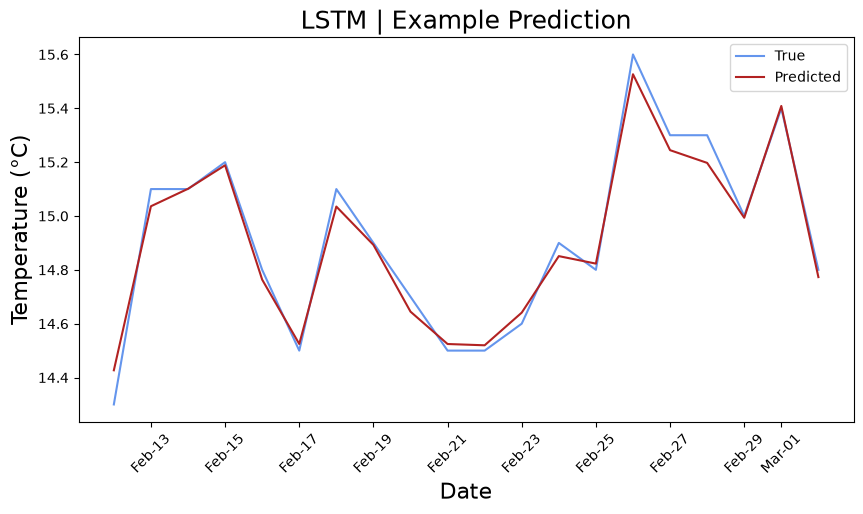

In [51]:
plot_df = test_x_df[:20].copy()
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(plot_df.date, plot_df.actual, label='True', color='cornflowerblue')
ax.plot(plot_df.date, plot_df.predicted, label='Predicted', color='firebrick')
ax.set_ylabel('Temperature (\u00b0C)', fontsize=16)
ax.set_xlabel('Date', fontsize=16)
ax.set_title('LSTM | Example Prediction', fontsize=18)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
ax.tick_params(axis='x', labelrotation=45)
plt.show()

In [52]:
mse = np.mean([x**2 for x in test_x_df.errors])
rmse = np.sqrt(mse)
r_2 = r2_score(y_test, y_pred)

print(f'RMSE = {round(rmse, 2)}')
print(f'r2 score = {round(r_2, 2)}')

RMSE = 0.27
r2 score = 0.99


##### RMSE and R2 Score are 0.27 and 0.99 respectively for the LSTM model trained on the no wind dataset. This is a significant improvement from the baseline RMSE = 0.56, however the R2 score is nearly the same as the baseline.